# 6 — Sensing and State Estimation

What the robot can actually know · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/06-sensing/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Six weeks, zero sensors

Both controllers we have built are **open loop**. The LIPM walker
follows a plan computed before it started moving. The CPG oscillates on
a timer. Neither has ever looked at the robot.

That is why the CPG fell every time, and why the LIPM walker drifts
sideways with nothing to pull it back.

Today the robot finds out about itself. This is the week that makes
feedback possible — and the observation vector we build here is exactly
what a learned policy will consume from Week 8 onward.

------------------------------------------------------------------------

## The cheating we have been doing

In simulation you can ask the robot anything:

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

print(f"pelvis position in the world : {np.round(data.qpos[:3], 3)}")
print(f"orientation quaternion       : {np.round(data.qpos[3:7], 3)}")

pelvis position in the world : [0.   0.   0.79]
orientation quaternion       : [1. 0. 0. 0.]

**A real robot knows neither of these.** There is no sensor for “where
am I in the room” and none for absolute attitude. Everything in
`qpos[:7]` is *privileged* information the simulator happens to have.

Build a controller on it and it cannot leave the simulator.

------------------------------------------------------------------------

## What the G1 actually has

In [2]:
for i in range(model.nsensor):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    kind = mujoco.mjtSensor(model.sensor_type[i]).name.replace("mjSENS_", "")
    print(f"  {kind:14s} dim={model.sensor_dim[i]}  {name}")
print(f"\n  total sensordata: {model.nsensordata} numbers")

  GYRO           dim=3  imu-torso-angular-velocity
  ACCELEROMETER  dim=3  imu-torso-linear-acceleration
  GYRO           dim=3  imu-pelvis-angular-velocity
  ACCELEROMETER  dim=3  imu-pelvis-linear-acceleration

  total sensordata: 12 numbers

**Two IMUs** — torso and pelvis — each a gyroscope plus an
accelerometer. Twelve numbers per timestep, and that is the entire
sensory world of this robot.

No cameras. No joint torque sensors. No foot contact switches. Joint
*encoders* are implicit: a real robot reads its own joint angles, which
is why using `qpos[7:]` is fair while using `qpos[:7]` is not.

------------------------------------------------------------------------

## What an accelerometer really measures

Not acceleration. **Specific force** — the non-gravitational force per
unit mass. A device sitting still on a table is being pushed *up* by the
table:

In [3]:
for _ in range(300):
    mujoco.mj_step(model, data)
gyro, accel = soc4180.read_imu(model, data, "torso")
print(f"at rest  : accel = {np.round(accel, 3)}   |accel| = {np.linalg.norm(accel):.3f}")

falling = soc4180.keyframe_data(model, "stand")
falling.qpos[2] += 1.0                      # drop it
mujoco.mj_forward(model, falling)
mujoco.mj_step(model, falling)
_, accel_ff = soc4180.read_imu(model, falling, "torso")
print(f"in free fall: accel = {np.round(accel_ff, 3)}")

at rest  : accel = [ 0.03 -0.    9.81]   |accel| = 9.810
in free fall: accel = [-0.  0.  0.]

Standing still it reads **9.81 upward**. In free fall it reads **zero**
— nothing is pushing it. That is the whole reason an accelerometer is a
*tilt* sensor: at rest, the direction it reports is “down”.

------------------------------------------------------------------------

## Gravity is the only compass

Rotate the body and gravity moves in the body’s frame. That vector is
the robot’s attitude reference:

In [4]:
print(f"gravity in the body frame (upright): {np.round(soc4180.gravity_body(data), 4)}")
print(f"roll, pitch from the accelerometer : "
      f"{np.round(np.degrees(soc4180.tilt_from_accel(accel)), 3)} deg")

gravity in the body frame (upright): [-0.001  0.    -1.   ]
roll, pitch from the accelerometer : [-0.003 -0.175] deg

Two things this gives you, and one it does not:

- **roll and pitch** — recoverable, because gravity is not aligned with
  either
- **yaw** — *not* recoverable. Spin about the vertical axis and gravity
  does not move. A gyroscope drifts; a magnetometer is unreliable
  indoors near motors

Locomotion policies therefore observe **gravity in the body frame**
rather than absolute pose. It is the largest piece of attitude a real
robot can honestly know.

------------------------------------------------------------------------

## In simulation the sensors are perfect

In [5]:
a = soc4180.keyframe_data(model, "stand")
b = soc4180.keyframe_data(model, "stand")
for _ in range(200):
    mujoco.mj_step(model, a); mujoco.mj_step(model, b)
print(f"two identical runs, identical sensordata: {np.array_equal(a.sensordata, b.sensordata)}")
print(f"noise declared in the model: {np.unique(model.sensor_noise)}  (gyro, accel)")

two identical runs, identical sensordata: True
noise declared in the model: [0.0005 0.01  ]  (gyro, accel)

The MJCF declares noise magnitudes, but this MuJoCo build applies none —
readings are **exactly** deterministic.

That is convenient and dishonest. A real gyroscope has a slowly
wandering bias; a real accelerometer is noisy and lags. **We will inject
those ourselves**, because an estimator tested on perfect sensors
teaches nothing.

------------------------------------------------------------------------

## Watch the assumption break

Tilt-from-gravity assumes the accelerometer sees *only* gravity. Walk,
and it does not:

In [6]:
from soc4180.walking import WalkingController, GaitParams

controller = WalkingController(model, GaitParams(n_steps=8))
sim = controller.initial_data()

log = []
while sim.time < controller.total_time:
    sim.ctrl[:] = controller.control(sim.time)
    mujoco.mj_step(model, sim)
    g, a = soc4180.read_imu(model, sim, "torso")
    truth = soc4180.gravity_body(sim)
    log.append([sim.time, *g, *a,
                np.arctan2(-truth[1], -truth[2]),
                np.arctan2(truth[0], np.hypot(truth[1], truth[2]))])

log = np.array(log)
walk = log[log[:, 0] > controller.params.settle_time]
mag = np.linalg.norm(walk[:, 4:7], axis=1)
print(f"|accel| during the walk : {mag.min():.2f} .. {mag.max():.2f} m/s^2")
print(f"                          (it would be 9.81 if only gravity acted)")
print(f"true roll  : {np.degrees(walk[:,7]).min():+.2f} .. {np.degrees(walk[:,7]).max():+.2f} deg")

|accel| during the walk : 3.36 .. 19.34 m/s^2
                          (it would be 9.81 if only gravity acted)
true roll  : -6.11 .. +4.57 deg

The accelerometer swings from **3.4 to 19.3 m/s²**. Half of that is the
robot, not the planet.

------------------------------------------------------------------------

## Seeing the corruption

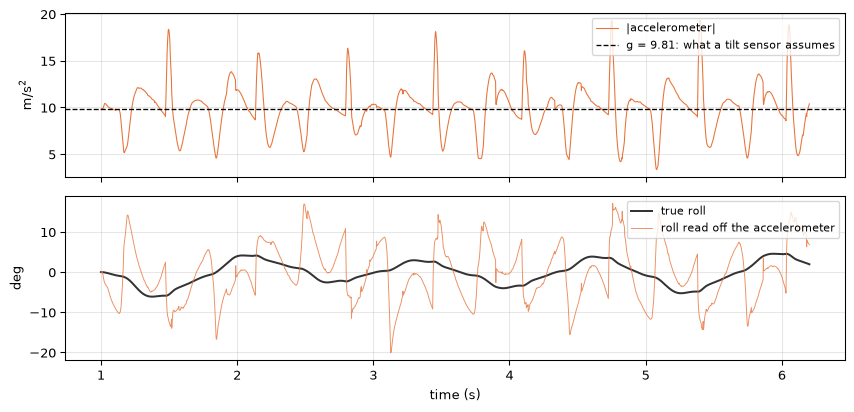

In [7]:
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True)
ax0.plot(walk[:, 0], mag, lw=0.8, color="#e8743b", label="|accelerometer|")
ax0.axhline(9.81, color="k", ls="--", lw=1, label="g = 9.81: what a tilt sensor assumes")
ax0.set_ylabel("m/s$^2$"); ax0.legend(fontsize=8, loc="upper right"); ax0.grid(alpha=0.3)
ax1.plot(walk[:, 0], np.degrees(walk[:, 7]), lw=1.5, color="0.2", label="true roll")
ax1.plot(walk[:, 0], np.degrees(np.arctan2(walk[:, 5], walk[:, 6])), lw=0.7, color="#e8743b",
         alpha=0.8, label="roll read off the accelerometer")
ax1.set_ylabel("deg"); ax1.set_xlabel("time (s)"); ax1.legend(fontsize=8, loc="upper right")
ax1.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Every spike in the top plot is a footfall. Each one lands in the bottom
plot as a tilt that never happened — the body did not roll twenty
degrees, the sensor was kicked.

------------------------------------------------------------------------

## Neither sensor is enough

In [8]:
t = walk[:, 0]; gyro_w = walk[:, 1:4]; acc_w = walk[:, 4:7]; roll_true = walk[:, 7]
dt = float(np.mean(np.diff(t)))

acc_roll = np.arctan2(acc_w[:, 1], acc_w[:, 2])
print(f"accelerometer only : mean err {np.degrees(np.abs(acc_roll-roll_true)).mean():5.2f} deg, "
      f"worst {np.degrees(np.abs(acc_roll-roll_true)).max():5.2f} deg")

def integrate(bias):
    r = np.empty(len(t)); r[0] = roll_true[0]
    for k in range(1, len(t)):
        r[k] = r[k-1] + (gyro_w[k, 0] + bias) * dt
    return r

for bias in (0.0, 0.01):
    r = integrate(bias)
    print(f"gyroscope only, bias {bias:.3f} rad/s : final err "
          f"{np.degrees(abs(r[-1]-roll_true[-1])):5.2f} deg")

accelerometer only : mean err  6.09 deg, worst 20.59 deg
gyroscope only, bias 0.000 rad/s : final err  0.13 deg
gyroscope only, bias 0.010 rad/s : final err  2.85 deg

**Complementary failure modes.** The accelerometer is wrong *now* but
never gets worse. The gyroscope is right *now* but gets worse forever. A
perfect gyro is near-exact — which is precisely why we injected a bias
to see the real problem.

------------------------------------------------------------------------

## Blend them

Trust the gyroscope over short intervals; let gravity correct it slowly.

$$\theta_k = \alpha\,(\theta_{k-1} + \omega_k \Delta t) \;+\; (1-\alpha)\,\theta_{\text{accel}}$$

In [9]:
def run_filter(alpha, bias=0.01):
    f = soc4180.ComplementaryFilter(dt=dt, alpha=alpha, roll=roll_true[0])
    out = []
    for k in range(len(t)):
        g = gyro_w[k].copy(); g[0] += bias          # a realistically biased gyro
        out.append(f.update(g, acc_w[k])[0])
    return np.array(out)

for alpha in (0.90, 0.98, 0.995, 1.0):
    est = run_filter(alpha)
    label = "1.0 (gyro only)" if alpha == 1.0 else f"{alpha}"
    print(f"  alpha = {label:<16} mean err {np.degrees(np.abs(est-roll_true)).mean():5.2f} deg,"
          f"  final err {np.degrees(abs(est[-1]-roll_true[-1])):5.2f} deg")

  alpha = 0.9              mean err  5.65 deg,  final err  5.87 deg
  alpha = 0.98             mean err  3.52 deg,  final err  5.25 deg
  alpha = 0.995            mean err  1.46 deg,  final err  1.37 deg
  alpha = 1.0 (gyro only)  mean err  1.38 deg,  final err  2.86 deg

At $\alpha = 0.995$ the **final** error is 1.37 deg, against 2.85 deg
for the drifting gyroscope and far worse for the accelerometer.

Read the two columns carefully: $\alpha = 1.0$ has a marginally *lower
mean* error but twice the final error. That gap is drift, and drift only
grows – which is why mean error is the wrong way to judge an estimator
you intend to run for an hour.

------------------------------------------------------------------------

## What $\alpha$ really sets

Write the update in the $z$-domain and it splits into two filters that
sum to one:

$$\Theta = \underbrace{\frac{1-\alpha}{1-\alpha z^{-1}}}_{\text{low-pass on the accelerometer}}\;\Theta_{\text{accel}}
\;+\;
\underbrace{\frac{\alpha\,\Delta t}{1-\alpha z^{-1}}}_{\text{integrates the gyro, high-pass}}\;\Omega$$

The pole at $z = \alpha$ gives a time constant
$\tau = -\Delta t / \ln\alpha
\approx \alpha\,\Delta t / (1-\alpha)$: **how long the gyroscope is
trusted before gravity has the last word**.

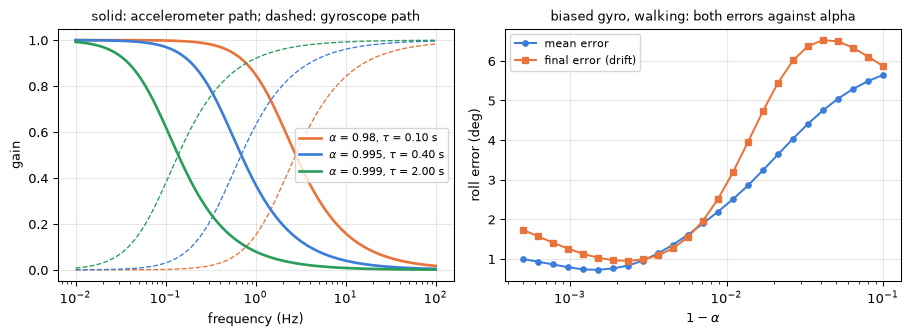

mean error is smallest at alpha = 0.9985 (tau = 1.32 s), final error at alpha = 0.9977

In [10]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6))
f = np.logspace(-2, 2, 300)
for alpha, col in ((0.98, "#e8743b"), (0.995, "#3b7dd8"), (0.999, "#2a9d5c")):
    z = np.exp(2j * np.pi * f * dt)
    low = np.abs((1 - alpha) / (1 - alpha / z))
    tau = -dt / np.log(alpha)
    ax0.semilogx(f, low, lw=2, color=col, label=fr"$\alpha$ = {alpha}, $\tau$ = {tau:.2f} s")
    ax0.semilogx(f, 1 - low, lw=1, ls="--", color=col)
ax0.set_xlabel("frequency (Hz)"); ax0.set_ylabel("gain"); ax0.legend(fontsize=8)
ax0.set_title("solid: accelerometer path; dashed: gyroscope path", fontsize=10); ax0.grid(alpha=0.3)

alphas = 1 - np.logspace(-3.3, -1, 25)
mean_err, final_err = [], []
for alpha in alphas:
    est = run_filter(alpha)
    mean_err.append(np.degrees(np.abs(est - roll_true)).mean())
    final_err.append(np.degrees(abs(est[-1] - roll_true[-1])))
ax1.semilogx(1 - alphas, mean_err, "o-", ms=4, lw=1.5, color="#3b7dd8", label="mean error")
ax1.semilogx(1 - alphas, final_err, "s-", ms=4, lw=1.5, color="#e8743b", label="final error (drift)")
ax1.set_xlabel(r"$1 - \alpha$"); ax1.set_ylabel("roll error (deg)"); ax1.legend(fontsize=8)
ax1.set_title("biased gyro, walking: both errors against alpha", fontsize=10); ax1.grid(alpha=0.3)
fig.tight_layout(); plt.show()
best_mean, best_final = alphas[np.argmin(mean_err)], alphas[np.argmin(final_err)]
print(f"mean error is smallest at alpha = {best_mean:.4f} (tau = {-dt / np.log(best_mean):.2f} s), "
      f"final error at alpha = {best_final:.4f}")

Both errors bottom out near $\alpha \approx 0.998$ — trust the gyroscope
for about a second. Go **left** (trust it longer) and the bias leaks
back in; go **right** (trust gravity sooner) and every footfall leaks in
instead. Where the minimum sits depends on how bad the gyroscope is: a
worse bias pushes it to the right, a rougher gait to the left. $\alpha$
is not a constant, it is a claim about your sensors.

------------------------------------------------------------------------

## Seeing it

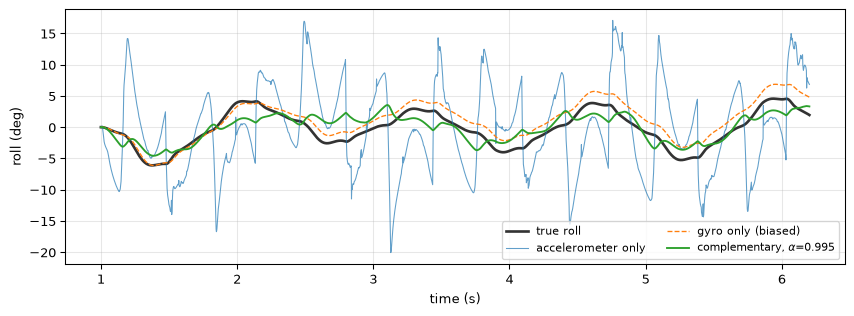

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t, np.degrees(roll_true), lw=2, color="0.2", label="true roll")
ax.plot(t, np.degrees(acc_roll), lw=0.8, alpha=0.7, label="accelerometer only")
ax.plot(t, np.degrees(integrate(0.01)), lw=1.0, ls="--", label="gyro only (biased)")
ax.plot(t, np.degrees(run_filter(0.995)), lw=1.4, label="complementary, $\\alpha$=0.995")
ax.set_xlabel("time (s)"); ax.set_ylabel("roll (deg)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

The dashed line walks away. The thin line is jagged. The filter is
neither.

------------------------------------------------------------------------

## Designing an observation

This is the week’s real product. What may a policy be given?

| Quantity                    | Real robot?             | Use it  |
|-----------------------------|-------------------------|---------|
| Joint angles `qpos[7:]`     | encoders                | **yes** |
| Joint velocities `qvel[6:]` | differentiated encoders | **yes** |
| Gravity in body frame       | IMU + filter            | **yes** |
| Angular velocity            | gyroscope               | **yes** |
| Previous action             | it commanded it         | **yes** |
| Body height `qpos[2]`       | no sensor               | no      |
| World position `qpos[:2]`   | no sensor               | no      |
| Foot contact forces         | not on this robot       | no      |

In [12]:
obs = np.concatenate([
    soc4180.gravity_body(sim),                       # 3
    soc4180.read_imu(model, sim, "torso")[0],        # 3 angular velocity
    sim.qpos[7:],                                    # 29 joint angles
    sim.qvel[6:],                                    # 29 joint velocities
])
print(f"observation vector: {obs.shape[0]} numbers, every one measurable on hardware")

observation vector: 64 numbers, every one measurable on hardware

------------------------------------------------------------------------

## The observation, drawn to scale

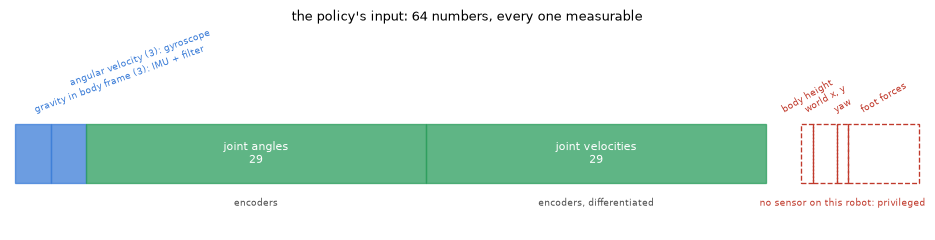

In [13]:
blocks = [("gravity in body frame", 3, "IMU + filter", "#3b7dd8"),
          ("angular velocity", 3, "gyroscope", "#3b7dd8"),
          ("joint angles", 29, "encoders", "#2a9d5c"),
          ("joint velocities", 29, "encoders, differentiated", "#2a9d5c")]
denied = [("body height", 1), ("world x, y", 2), ("yaw", 1), ("foot forces", 6)]
fig, ax = plt.subplots(figsize=(10, 2.6))
x = 0
for k, (name, n, src, col) in enumerate(blocks):
    ax.add_patch(plt.Rectangle((x, 0), n, 1, color=col, alpha=0.75))
    if n > 6:
        ax.text(x + n / 2, 0.5, f"{name}\n{n}", ha="center", va="center", fontsize=8, color="w")
        ax.text(x + n / 2, -0.25, src, ha="center", va="top", fontsize=7, color="0.3")
    else:                                    # narrow: label above, staggered
        ax.text(x + n / 2, 1.15 + 0.45 * k, f"{name} ({n}): {src}", ha="left", va="bottom",
                fontsize=7, color=col, rotation=20)
    x += n
xd = x + 3
for name, n in denied:
    ax.add_patch(plt.Rectangle((xd, 0), n, 1, fill=False, ls="--", color="#c0392b"))
    ax.text(xd + n / 2, 1.15, name, ha="center", va="bottom", fontsize=7, rotation=30, color="#c0392b")
    xd += n
ax.text(x + 1.5 + 5, -0.25, "no sensor on this robot: privileged", ha="center", va="top", fontsize=7, color="#c0392b")
ax.set_xlim(-0.5, xd + 0.5); ax.set_ylim(-0.8, 2.6); ax.axis("off")
ax.set_title(f"the policy's input: {x} numbers, every one measurable", fontsize=10)
fig.tight_layout(); plt.show()

Sixty-four numbers in, twelve joint targets out. The dashed boxes are
things the simulator knows and a real robot never will — which is
exactly where the next slide’s trick comes in.

------------------------------------------------------------------------

## Privileged information

Some quantities are unavailable at deployment but *known* during
training — body height, contact forces, the terrain, the friction
coefficient.

Throwing them away entirely is wasteful. The standard trick, which you
will meet again in Week 10:

- the **policy** sees only what a real robot can measure
- the **value function** may see everything, since it is discarded after
  training

This is **asymmetric actor-critic**. The critic gets a clearer view of
how good a state was; the actor stays deployable.

The discipline starts today: *what does the robot know, and how does it
know it?*

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/06-sensing/lab_imu.py
```

Three arrows hang from the torso IMU, each an estimate of *down* made
from the IMU alone and drawn back in the world — so **right means
vertical**. Orange is the accelerometer, cyan the integrated gyroscope,
green the student’s own `my_filter`; a thin white arrow is the truth.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | ctrl-drag the standing robot | orange swings during the push and is right after; the student says what an accelerometer measures |
| 2 | `N` (gyro bias + accel noise), `ENTER` twice | cyan leans further every time: drift, named |
| 3 | write `my_filter` | green inside white, standing, pushed, and with `N` on |
| 4 | `W` to walk, then `[` `]` to sweep $\alpha$ | the student finds the worst $\alpha$ and names the trade |
| 5 | `SITE = "pelvis"` | an explanation either way |

------------------------------------------------------------------------

## Exercises

1.  **Noise, properly.** Add Gaussian noise to the accelerometer at the
    magnitude the MJCF declares (0.01). How much does the
    accelerometer-only estimate degrade, and how much does the filter?
2.  **Sweep $\alpha$.** Plot mean and final error against $\alpha$ from
    0.9 to 1.0. Where is the optimum, and how sharp is it?
3.  **Latency.** Delay the IMU by 20 ms before filtering. Which
    estimator suffers most, and does a different $\alpha$ compensate?
4.  **The second IMU.** The pelvis IMU has been ignored all lecture.
    Does averaging both improve the estimate? Explain the result either
    way.
5.  **Yaw.** Try to estimate yaw from these sensors. Show where it
    fails, and say what hardware would fix it.
6.  **Close the loop.** Feed the estimated roll back into the Week 4
    walker as a small lateral correction. Does it reduce the sideways
    drift?

------------------------------------------------------------------------

## Next week

**07 — from control to learning.** We stop deriving controllers and
start specifying *problems*: states, actions, rewards, and episodes. The
observation vector built today becomes the input to a policy, and the
walker you wrote by hand becomes the baseline it has to beat.